In [67]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [68]:
import numpy as np
import pandas as pd


def assign_column_by_ratio(
    df,
    dataset_name,
    column_name,
    ratio_dict,
    dataset_col="dataset",
    random_state=42,
):
    """
    按比例重新分配某个 dataset 子集中的 column_name。

    Parameters
    ----------
    df : pd.DataFrame
    dataset_name : str
        需要修改的 dataset 名
    column_name : str
        要修改的列名（如 'modality'）
    ratio_dict : dict
        例如 {"CT":282, "MRI":181, "x-ray":179}
    dataset_col : str
        dataset 列名
    random_state : int
        随机种子

    Returns
    -------
    df_new : pd.DataFrame
    """

    df = df.copy()

    # 选取子集
    mask = df[dataset_col] == dataset_name
    subset_idx = df[mask].index
    N = len(subset_idx)

    if N == 0:
        print("No rows found for this dataset.")
        return df

    # ----------------------------
    # 1️⃣ 计算比例
    # ----------------------------
    total_given = sum(ratio_dict.values())
    proportions = {k: v / total_given for k, v in ratio_dict.items()}

    # ----------------------------
    # 2️⃣ 计算目标整数数量
    # ----------------------------
    raw_counts = {k: proportions[k] * N for k in proportions}

    # 先取 floor
    final_counts = {k: int(np.floor(v)) for k, v in raw_counts.items()}

    # 剩余数量分配（防止总数不等）
    remainder = N - sum(final_counts.values())

    # 按小数部分大小排序分配剩余
    fractional = sorted(
        raw_counts.items(),
        key=lambda x: x[1] - np.floor(x[1]),
        reverse=True,
    )

    for i in range(remainder):
        final_counts[fractional[i][0]] += 1

    # ----------------------------
    # 3️⃣ 随机打乱并赋值
    # ----------------------------
    np.random.seed(random_state)
    shuffled_idx = np.random.permutation(subset_idx)

    start = 0
    for category, count in final_counts.items():
        end = start + count
        df.loc[shuffled_idx[start:end], column_name] = category
        start = end

    return df

In [69]:
list_data = []

list_data += [{"dataset": "CXP", "id": "na", "modality": "x-ray", "organ": "chest", "task": "diagnosis"}] * (
    223414 + 234
)
list_data += [{"dataset": "Camelyon", "id": "na", "modality": "pathology", "organ": "breast", "task": "diagnosis"}] * (
    3680 + 920
)
list_data += [{"dataset": "HAM", "id": "na", "modality": "dermoscopy", "organ": "skin", "task": "diagnosis"}] * (
    8137 + 1811
)
list_data += [{"dataset": "PAPILA", "id": "na", "modality": "color fundus", "organ": "eye", "task": "diagnosis"}] * (
    364 + 56
)
list_data += [{"dataset": "GF3300", "id": "na", "modality": "OCT", "organ": "eye", "task": "diagnosis"}] * (2706 + 594)
list_data += [
    {"dataset": "FairVLMed-diag", "id": "na", "modality": "SLO fundus", "organ": "eye", "task": "diagnosis"}
] * 10000

# vqa
#
# SLAKE
# https://arxiv.org/pdf/2102.09542
# The images include 140 head CTs or MRIs, 41 neck CTs,
# 219 chest X-Rays or CTs, 201 abdomen CTs or MRIs, and
# 41 pelvic cavity CTs. The distribution is shown in Figure 2
# (Left). Among these images, there are 282 CTs, 181 MRIs,
# and 179 X-Rays.
list_data += [{"dataset": "SLAKE", "id": "na", "modality": "radiology", "organ": "others", "task": "vqa"}] * (
    1061 + 4919
)

list_data += [{"dataset": "PathVQA", "id": "na", "modality": "pathology", "organ": "lymphatic", "task": "vqa"}] * (
    6719 + 19654
)

# VQA-RAD
# https://www.nature.com/articles/sdata2018251#Sec8
# In total, we selected 104 head axial single-slice CTs or MRIs, 107 chest x-rays, and 104 abdominal axial CTs.
list_data += [{"dataset": "VQA-RAD", "id": "na", "modality": "radiology", "organ": "whole body", "task": "vqa"}] * (
    451 + 1793
)

list_data += [{"dataset": "FairVLMed-vqa", "id": "na", "modality": "SLO fundus", "organ": "eye", "task": "vqa"}] * (
    3994 + 14000
)

list_data += [{"dataset": "OmniMedVQA", "id": "na", "modality": "universal", "organ": "skip", "task": "vqa"}] * (
    2677 + 6186
)

list_data += [{"dataset": "MedXpertQA", "id": "na", "modality": "skip", "organ": "whole body", "task": "vqa"}] * (2000)

df = pd.DataFrame(list_data)
df

,dataset,id,modality,organ,task
0,CXP,na,x-ray,chest,diagnosis
1,CXP,na,x-ray,chest,diagnosis
2,CXP,na,x-ray,chest,diagnosis
3,CXP,na,x-ray,chest,diagnosis
4,CXP,na,x-ray,chest,diagnosis
...,...,...,...,...,...
315365,MedXpertQA,na,skip,whole body,vqa
315366,MedXpertQA,na,skip,whole body,vqa
315367,MedXpertQA,na,skip,whole body,vqa
315368,MedXpertQA,na,skip,whole body,vqa


In [70]:
df = assign_column_by_ratio(
    df, dataset_name="SLAKE", column_name="modality", ratio_dict={"CT": 282, "MRI": 181, "x-ray": 179}
)
df = assign_column_by_ratio(
    df,
    dataset_name="SLAKE",
    column_name="organ",
    ratio_dict={"head": 0.23, "chest": 0.34,
                "abdomen": 0.31, "pelvic": 0.6, "neck": 0.6},
)
df = assign_column_by_ratio(
    df, dataset_name="VQA-RAD", column_name="modality", ratio_dict={"CT": 104, "MRI": 104, "x-ray": 107}
)
df = assign_column_by_ratio(
    df,
    dataset_name="VQA-RAD",
    column_name="organ",
    ratio_dict={"head": 104, "chest": 107, "abdomen": 104},
)
df = assign_column_by_ratio(
    df,
    dataset_name="OmniMedVQA",
    column_name="modality",
    ratio_dict={
        # "colposcopy": 338,
        "CT": 15836,
        "digital photography": 2786,
        "color fundus": 10815,
        "SLO fundus": 9785,
        "MRI": 32705,
        "OCT": 4646,
        "dermoscopy": 6762,
        "endoscopy": 1877 + 338,
        "microscopy": 21743,
        "x-ray": 9711,
        "ultrasound": 10991,
    },
)


# df = assign_column_by_ratio(
#     df,
#     dataset_name="OmniMedVQA",
#     column_name="organ",
#     ratio_dict={
#         "head": 0.23,
#         "chest": 871 + 199 + 910 + ,
#         "abdomen": 338 + 1877,
#         "eye": 10815 + 9785 + 4646,
#         "skin": 6762,
#     },
# )

df = assign_column_by_ratio(
    df,
    dataset_name="MedXpertQA",
    column_name="organ",
    ratio_dict={
        "chest": 320,
        "abdomen": 168,
        "abdomen": 74,
        "skin": 225,
        "lymphatic": 81,
        "muscular": 46,
        "head": 231,
        "others": 18,
        "chest": 192,
        "skeletal": 491,
        "pelvic": 98 + 56,
    },
)

In [71]:
import json

with open(
    "/media/yesindeed/DATADRIVE1/mount/remote_cse/datasets/MedXpertQA/MM/test.jsonl", "r", encoding="utf-8"
) as f:
    data = [json.loads(line) for line in f]

organs = [x["body_system"] for x in data]
unique_vals, counts = np.unique(organs, return_counts=True)
dict(zip(unique_vals, counts))

{np.str_('Cardiovascular'): np.int64(320),
 np.str_('Digestive'): np.int64(168),
 np.str_('Endocrine'): np.int64(74),
 np.str_('Integumentary'): np.int64(225),
 np.str_('Lymphatic'): np.int64(81),
 np.str_('Muscular'): np.int64(46),
 np.str_('Nervous'): np.int64(231),
 np.str_('Other / NA'): np.int64(18),
 np.str_('Reproductive'): np.int64(98),
 np.str_('Respiratory'): np.int64(192),
 np.str_('Skeletal'): np.int64(491),
 np.str_('Urinary'): np.int64(56)}

In [72]:
df.loc[df["dataset"] == "OmniMedVQA"]["modality"].value_counts()

modality
MRI                    2265
microscopy             1506
CT                     1097
ultrasound              761
color fundus            749
SLO fundus              677
x-ray                   672
dermoscopy              468
OCT                     322
digital photography     193
endoscopy               153
Name: count, dtype: int64

In [73]:
df.loc[df["modality"] != "skip"]["modality"].value_counts()

modality
x-ray                  226749
pathology               30973
SLO fundus              28671
dermoscopy              10416
MRI                      4692
CT                       4465
OCT                      3622
microscopy               1506
color fundus             1169
ultrasound                761
digital photography       193
endoscopy                 153
Name: count, dtype: int64

In [74]:
df.loc[df["organ"] != "skip"]["organ"].value_counts()

organ
chest        225642
eye           31714
lymphatic     26480
skin          10246
breast         4600
pelvic         1929
abdomen        1730
neck           1725
head           1707
skeletal        649
muscular         61
others           24
Name: count, dtype: int64

In [75]:
df.loc[df["dataset"] != "skip"]["dataset"].value_counts()

dataset
CXP               223648
PathVQA            26373
FairVLMed-vqa      17994
FairVLMed-diag     10000
HAM                 9948
OmniMedVQA          8863
SLAKE               5980
Camelyon            4600
GF3300              3300
VQA-RAD             2244
MedXpertQA          2000
PAPILA               420
Name: count, dtype: int64

In [76]:
anatomical_region_dict = {
    "Head and Neck": 35146,
    "Thorax": 230242,
    "Abdomen": 1730,
    "Pelvis": 1929,
    "Lymphatic": 26480,
    "Skin": 10246,
    "Musculoskeletal": 710,
    "Other": 24,
}

modality_dict = {
    "x-ray": 226749,
    "MRI": 4692,
    "CT": 4465,
    "histopathology": 30973 + 1506,
    "Color fundus": 1169,
    "OCT": 3622,
    "SLO": 28671,
    "dermoscopy": 10416,
    "ultrasound": 761,
    "endoscopy": 153,
    "others (vital signs, diagrams, documents, charts, tables, and others)": 523 + 193,
}

dataset_dict = {
    "CXP": 223648,
    "PathVQA": 26373,
    "FairVLMed-vqa": 17994,
    "FairVLMed-diag": 10000,
    "HAM": 9948,
    "OmniMedVQA": 8863,
    "SLAKE": 5980,
    "Camelyon": 4600,
    "GF3300": 3300,
    "VQA-RAD": 2244,
    "MedXpertQA": 2000,
    "PAPILA": 420,
}

diagnosis_datasets = list(
    df.loc[df["task"] == "diagnosis"]["dataset"].unique())
vqa_datasets = list(df.loc[df["task"] == "vqa"]["dataset"].unique())

vqa_datasets

['SLAKE', 'PathVQA', 'VQA-RAD', 'FairVLMed-vqa', 'OmniMedVQA', 'MedXpertQA']

x-ray: 72.24% (226749)
MRI: 1.49% (4692)
CT: 1.42% (4465)
histopathology: 10.35% (32479)
Color fundus: 0.37% (1169)
OCT: 1.15% (3622)
SLO: 9.13% (28671)
dermoscopy: 3.32% (10416)
ultrasound: 0.24% (761)
endoscopy: 0.05% (153)
others (vital signs, diagrams, documents, charts, tables, and others): 0.23% (716)


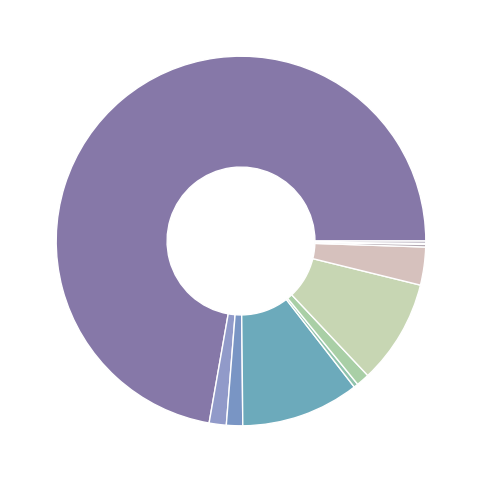

In [93]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# Sort by value (descending)
# -----------------------------
def sort_dict(d):
    items = d.items()
    labels = [i[0] for i in items]
    values = [i[1] for i in items]
    return labels, values


mod_labels, mod_values = sort_dict(modality_dict)
ana_labels, ana_values = sort_dict(anatomical_region_dict)

# -----------------------------
# Harmonized Color Palette
# (Muted purple–blue–green palette to match Fig.1)
# -----------------------------
palette = [
    "#5E4B8B",  # muted purple
    "#6C79B8",  # soft indigo
    "#4C72B0",  # calm blue
    "#3B8EA5",  # blue-green
    "#6BAF92",  # soft teal
    "#8CBF88",  # muted green
    "#B5C99A",  # light sage
    "#C9ADA7",  # dusty rose
    "#9A8C98",  # gray-purple
    "#7F8C8D",  # neutral gray
    "#B0A8B9",  # pale lavender
]

# Base harmonious palette (muted academic tones)
# palette = [
#     "#6D597A",  # muted purple
#     "#7A6C9D",  # soft lavender
#     "#5C6F91",  # steel blue
#     "#4F8A8B",  # muted teal
#     "#6BA292",  # soft green
#     "#8FB996",  # sage
#     "#B8C1A8",  # light olive gray
#     "#C9ADA7",  # dusty rose
#     "#9A8C98",  # gray-purple
#     "#7E8A97",  # blue gray
#     "#A3A3A3",  # neutral gray
# ]


def add_alpha_to_palette(palette, alpha=0.85):
    new_colors = []
    for c in palette:
        rgba = mcolors.to_rgba(c, alpha=alpha)
        new_colors.append(rgba)
    return new_colors


palette = add_alpha_to_palette(palette, alpha=0.75)

# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
size = 0.6  # donut width
radius = 1
pctdistance = 2


def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 1 else ""  # hide very small slices


# ---- Modality (Left) ----
ax.pie(
    mod_values,
    radius=radius,
    colors=palette[: len(mod_values)],
    # labels=mod_labels,
    # autopct=autopct_format,
    wedgeprops=dict(width=size, edgecolor="white"),
    textprops={"fontsize": 9},
    pctdistance=pctdistance,
    # alpha=0.5,
)
ax.set(aspect="equal")
# axes[0].set_title("Training Data Distribution by Modality", fontsize=12)

total = sum(mod_values)

for label, value in zip(mod_labels, mod_values):
    percent = value / total * 100
    print(f"{label}: {percent:.2f}% ({value})")


plt.savefig(
    "figures/bar_modalities.png",
    dpi=1000,
    bbox_inches="tight",
)

Anatomical Region Distribution:
Head and Neck: 11.47% (35146)
Thorax: 75.12% (230242)
Abdomen: 0.56% (1730)
Pelvis: 0.63% (1929)
Lymphatic: 8.64% (26480)
Skin: 3.34% (10246)
Musculoskeletal: 0.23% (710)
Other: 0.01% (24)


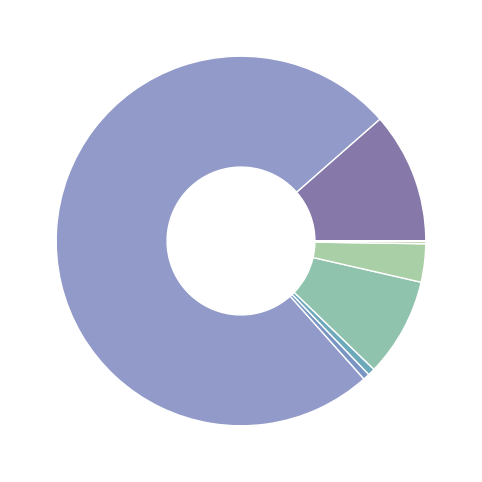

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ---- Anatomical Region (Right) ----
ax.pie(
    ana_values,
    radius=radius,
    colors=palette[: len(ana_values)],
    # labels=ana_labels,
    # autopct=autopct_format,
    wedgeprops=dict(width=size, edgecolor="white"),
    textprops={"fontsize": 9},
    pctdistance=pctdistance,
)
ax.set(aspect="equal")
# axes[1].set_title("Training Data Distribution by Anatomical Region", fontsize=12)

total = sum(ana_values)

print("Anatomical Region Distribution:")
for label, value in zip(ana_labels, ana_values):
    percent = value / total * 100
    print(f"{label}: {percent:.2f}% ({value})")

plt.savefig(
    "figures/bar_region.png",
    dpi=1000,
    bbox_inches="tight",
)

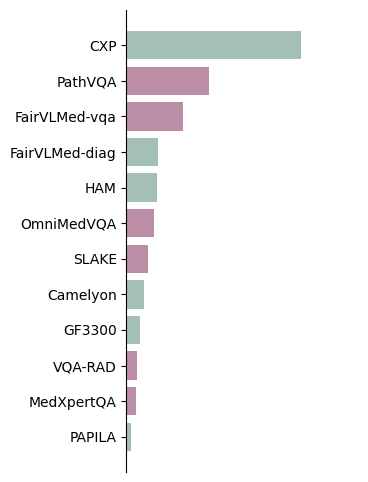

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

dataset_dict = {
    "CXP": 223648 / 4,
    "PathVQA": 26373,
    "FairVLMed-vqa": 17994,
    "FairVLMed-diag": 10000,
    "HAM": 9948,
    "OmniMedVQA": 8863,
    "SLAKE": 5980 + 1000,
    "Camelyon": 4600 + 1000,
    "GF3300": 3300 + 1000,
    "VQA-RAD": 2244 + 1000,
    "MedXpertQA": 2000 + 1000,
    "PAPILA": 420 + 1000,
}

# -------------------------
# 构造 DataFrame
# -------------------------
df_plot = pd.DataFrame({"dataset": dataset_dict.keys(), "size": dataset_dict.values()})

# ✅ 按 size 从大到小排序
df_plot = df_plot.sort_values("size", ascending=False)

# -------------------------
# 颜色设计（与主图和谐）
# -------------------------
# color_A = mcolors.to_rgba("#6C79B8", alpha=0.85)  # VQA
# color_B = mcolors.to_rgba("#8FB996", alpha=0.75)  # Non-VQA

color_A = mcolors.to_rgba("#b17a96", alpha=0.85)  # VQA
color_B = mcolors.to_rgba("#86aaa0", alpha=0.75)  # Non-VQA

df_plot["color"] = df_plot["dataset"].apply(lambda x: color_A if x in vqa_datasets else color_B)

# -------------------------
# 绘图
# -------------------------
plt.figure(figsize=(3, 6))

ax = plt.barh(
    df_plot["dataset"],
    df_plot["size"],
    color=df_plot["color"],
)

# ✅ 最大在最上面
plt.gca().invert_yaxis()


# -------------------------
# 美化（右下角风格）
# -------------------------
plt.xticks([])
plt.xlabel("")
plt.ylabel("")

plt.xlim([0, 223648 / 3])

# plt.yticks([])
# plt.gca().set_yticklabels([])

for spine in ["top", "right", "bottom"]:
    plt.gca().spines[spine].set_visible(False)

plt.gca().spines["left"].set_linewidth(0.8)

# plt.tight_layout()
plt.savefig("figures/dataset_bar.png", dpi=1000, bbox_inches="tight")